In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from pathlib import Path
import pynapple as nap

from scipy.stats import gaussian_kde

from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.data.loading import load_session
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2


In [2]:
mouse = 0
day = 0
session_type = 'OF1'
sorter = 'kilosort4'
storage = Path('/Users/harryclark/Downloads/COHORT12/')

alpha = 0.001
n_jobs = 8
n_shuffles = 100
seed = 1
class Args:
    def __init__(self,mouse,day,session_type,sorter,storage,alpha,n_jobs,n_shuffles,seed):
        self.mouse = mouse
        self.day = day
        self.session_type = session_type
        self.sorter = sorter
        self.storage = storage
        self.alpha = alpha
        self.n_jobs = n_jobs
        self.n_shuffles = n_shuffles
        self.seed = seed
args = Args(mouse,day,session_type,sorter,storage,alpha,n_jobs,n_shuffles,seed)

In [3]:
# Load session
gcs_ = pd.DataFrame()
ngs_ = pd.DataFrame()
gcs_and_ngs_ = pd.DataFrame()
ns_ = pd.DataFrame()
sc_ = pd.DataFrame()
ngs_ns_ = pd.DataFrame()
all_ = pd.DataFrame()


mouse_days = {20: [14,15,16,17,18,19,20,21,22,23,24,25,26],
              21: [15,16,17,18,19,20,21,22,23,24,25,26],
              22: [33,34,35,36,37,38,39,40,41],
              25: [16,17,18,19,20,21,22,23,24,25],
              26: [11,12,13,14,15,16,17,18,19],
              27: [16,17,18,19,20,21,22,23,24,26],
              28: [16,17,18,19,20,21,22,23,25],
              29: [16,17,18,19,20,21,22,23,25],
            }

for mouse, days in mouse_days.items():
    for day in days:

        [gcs, ngs, ns, sc, ngs_ns, all] = cell_classification_of1(mouse, day, percentile_threshold=95, verbose=False)
        gcs_and_ngs = pd.concat([gcs, ngs], ignore_index=True)
        _,_,_,_,_,clusters_VR = compute_vr_tcs(mouse, day)

        gcs_ = pd.concat([gcs_, gcs], ignore_index=True)
        ngs_ = pd.concat([ngs_, ngs], ignore_index=True)
        gcs_and_ngs_ = pd.concat([gcs_and_ngs_, gcs_and_ngs], ignore_index=True)
        ns_ = pd.concat([ns_, ns], ignore_index=True)
        sc_ = pd.concat([sc_, sc], ignore_index=True)
        ngs_ns_ = pd.concat([ngs_ns_, ngs_ns], ignore_index=True)
        all_ = pd.concat([all_, all], ignore_index=True)

print(f'there are this many cells at the moment, {len(all_)}')
print(f'there are this many gcs at the moment, {len(gcs_)}')
print(f'there are this many ngs at the moment, {len(ngs_)}')
print(f'there are this many ns at the moment, {len(ns_)}')

there are this many cells at the moment, 8209
there are this many gcs at the moment, 461
there are this many ngs at the moment, 5586
there are this many ns at the moment, 2162


In [4]:
# Flip SC_x
gcs_['SC_x'] = gcs_['SC_x'] * -1

# Cells below 3400
below_3400 = gcs_[gcs_['SC_x'] < 3400]
n_below = len(below_3400)
min_below = below_3400['SC_x'].min() if n_below > 0 else None
max_below = below_3400['SC_x'].max() if n_below > 0 else None

# Cells above or equal to 3400
above_3400 = gcs_[gcs_['SC_x'] >= 3400]
n_above = len(above_3400)
min_above = above_3400['SC_x'].min() if n_above > 0 else None
max_above = above_3400['SC_x'].max() if n_above > 0 else None

print(f"Cells below 3400: {n_below}, min: {min_below}, max: {max_below}")
print(f"Cells above or equal to 3400: {n_above}, min: {min_above}, max: {max_above}")

Cells below 3400: 331, min: 2700.0, max: 3390.0
Cells above or equal to 3400: 130, min: 3475.1733195179327, max: 3756.630588304794


In [5]:
print("Unique gcs_ brain_regions:", np.sort(gcs_['brain_region'].unique()))
print("Unique ngs_ brain_regions:", np.sort(ngs_['brain_region'].unique()))

Unique gcs_ brain_regions: ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'ENTm6' 'HPF' 'PAR' 'PRE']
Unique ngs_ brain_regions: ['ENTl6a' 'ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'ENTm6' 'HPF' 'PAR' 'PRE']


In [7]:
# Load the CSV file with all cluster brain locations
import pandas as pd

# Path to the CSV file
csv_path = '/Users/harryclark/Downloads/COHORT12/all_cluster_brain_locations_chris.csv'

# Load the CSV
all_clusters = pd.read_csv(csv_path)

# Function to determine cell identity
def get_cell_identity(row):
    mouse = row['mouse']
    day = row['day']
    cluster_id = row['cluster_id']
    # Check grid cells
    if ((gcs_['mouse'] == mouse) & (gcs_['day'] == day) & (gcs_['cluster_id'] == cluster_id)).any():
        return 'grid cell'
    # Check non-grid spatial cells
    elif ((ngs_['mouse'] == mouse) & (ngs_['day'] == day) & (ngs_['cluster_id'] == cluster_id)).any():
        return 'non-grid spatial cell'
    # Check other
    elif ((ns_['mouse'] == mouse) & (ns_['day'] == day) & (ns_['cluster_id'] == cluster_id)).any():
        return 'other'
    else:
        return 'unclassified'

# Apply the function to each row
all_clusters['cell_identity'] = all_clusters.apply(get_cell_identity, axis=1)

# drop unclassified cells (cells outside of the taretted brain areas)
all_clusters = all_clusters[all_clusters['cell_identity'] != 'unclassified']

print(f'length of all_clusters: {len(all_clusters)}')
print(f'n cells {len(gcs_)}, {len(ngs_)}, {len(ns_)}, = {len(gcs_)+len(ngs_)+len(ns_)}')
all_clusters.head()

all_clusters.to_csv('/Users/harryclark/Downloads/COHORT12/all_cluster_brain_locations_chris_with_identities.csv', index=False)

length of all_clusters: 8209
n cells 461, 5586, 2162, = 8209


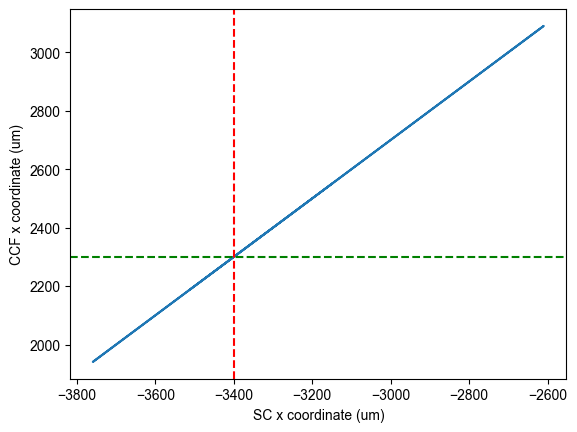

In [19]:
all_clusters = pd.read_csv('/Users/harryclark/Downloads/COHORT12/all_cluster_brain_locations_chris_with_identities.csv')
all_clusters

plt.plot(all_clusters['coord_SCs_x'], all_clusters['coord_CCFs_x'])
plt.xlabel('SC x coordinate (um)')
plt.ylabel('CCF x coordinate (um)')
plt.axvline(x=-3400, color='r', linestyle='--')
plt.axhline(y=2300, color='g', linestyle='--')

In [ ]:
all_clusters = pd.read_csv('/Users/harryclark/Downloads/COHORT12/all_cluster_brain_locations_chris_with_identities.csv')
all_clusters['coord_SCs_x'] = all_clusters['coord_SCs_x']*-1

gc_below = all_clusters[(all_clusters['cell_identity'] == 'grid cell') & (all_clusters['coord_SCs_x'] < 3400)]
gc_above = all_clusters[(all_clusters['cell_identity'] == 'grid cell') & (all_clusters['coord_SCs_x'] >= 3400)]
ngs_below = all_clusters[(all_clusters['cell_identity'] == 'non-grid spatial cell') & (all_clusters['coord_SCs_x'] < 3400)]
ngs_above = all_clusters[(all_clusters['cell_identity'] == 'non-grid spatial cell') & (all_clusters['coord_SCs_x'] >= 3400)]

print(f"Grid cells: <3400: {len(gc_below)}, >=3400: {len(gc_above)}")
print(f"Non-grid spatial cells: <3400: {len(ngs_below)}, >=3400: {len(ngs_above)}")

Grid cells: <3400: 331, >=3400: 130
Non-grid spatial cells: <3400: 2166, >=3400: 3420
